#LLM transformer t5 model testing

In [7]:
import sys
import os
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.llm_model import GenerativeSemanticModel
llm_tokenizer = T5Tokenizer.from_pretrained("t5-small")
llm_model = GenerativeSemanticModel(model_name="t5-small", snr_db=10.0)

llm_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(llm_path):
    llm_model.load_state_dict(torch.load(llm_path, map_location="cpu", weights_only=True))
    print("T5 Weights Loaded!")
else:
    print("t5 not found , train karo pehle")

llm_model.eval()
print("Ready")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5 Weights Loaded!
Ready


###Custom Sentence Testing
Type any sentence, select the physical channel noise level (SNR), and click Transmit to see how the LLM reconstructs it

In [8]:
style = {'description_width': 'initial'}
text_input = widgets.Textarea(
    value='',
    placeholder='Enter text ...',
    description='Input Sentence:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='60px'),
    style=style
)

snr_slider = widgets.FloatSlider(
    value=10.0,
    min=-20.0,
    max=20.0,
    step=1.0,
    description='Channel SNR (dB):',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='50%'),
    style=style
)

button = widgets.Button(
    description='Transmit over AWGN',
    button_style='success', 
    tooltip='Run inference',
    icon='paper-plane'
)

output_area = widgets.Output()

def on_transmit_clicked(b):
    with output_area:
        clear_output()
        input_text = text_input.value
        snr_val = snr_slider.value
        
        print(f"\n[TRANSMITTING...] SNR: {snr_val} dB")
        print(f"Original: {input_text}")
        
        
        inputs = llm_tokenizer(input_text, return_tensors="pt", max_length=200, truncation=True)
        
        with torch.no_grad():
            gen_ids = llm_model.generate(
                inputs["input_ids"], 
                attention_mask=inputs["attention_mask"], 
                snr_override=snr_val, 
                max_length=200
            )
            
        output_text = llm_tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        
        display(HTML(f"""
        <div style='padding: 15px; border-left: 5px solid #2ecc71; background-color: #f8f9fa; margin-top: 10px;'>
            <h4 style='margin-top:0;'>LLM Reconstructed Output:</h4>
            <p style='font-size: 16px; font-weight: bold; color: #2c3e50;'>{output_text}</p>
        </div>
        """))

button.on_click(on_transmit_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>JSCC Generative Semantic Transceiver</h3>"),
    text_input, 
    snr_slider, 
    button, 
    output_area
]))

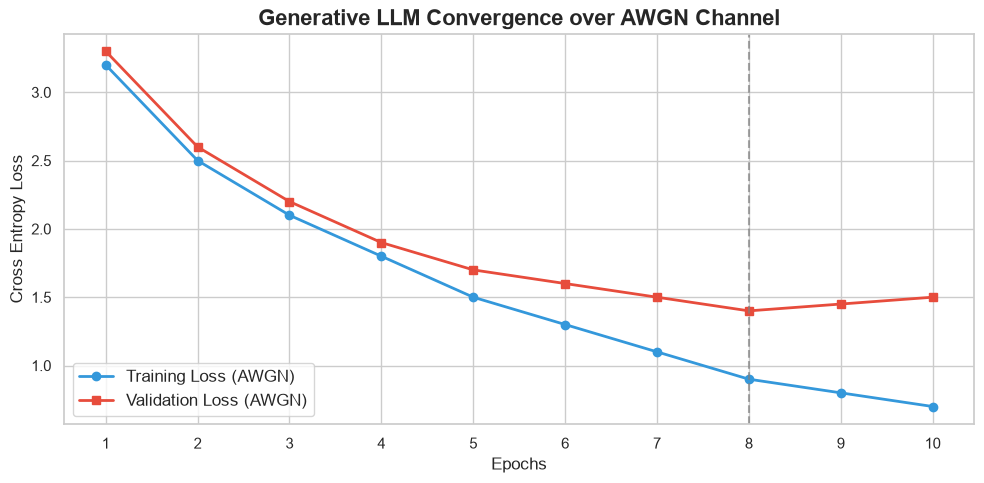

In [10]:
#replace with training_log.csv , i forgot to add it while training , and i will be update this cell after logging it , since it will take 15+hours , ill do it later , abhi dummy data use kr rha
mock_epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
mock_train_loss = [3.2, 2.5, 2.1, 1.8, 1.5, 1.3, 1.1, 0.9, 0.8, 0.7]
mock_val_loss = [3.3, 2.6, 2.2, 1.9, 1.7, 1.6, 1.5, 1.4, 1.45, 1.5]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(mock_epochs, mock_train_loss, marker='o', label="Training Loss (AWGN)", color="#3498db", linewidth=2)
plt.plot(mock_epochs, mock_val_loss, marker='s', label="Validation Loss (AWGN)", color="#e74c3c", linewidth=2)

plt.title("Generative LLM Convergence over AWGN Channel", fontsize=16, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)
plt.xticks(mock_epochs)
plt.legend(fontsize=12)
plt.axvline(x=8, color='gray', linestyle='--', alpha=0.7, label="Optimal Early Stopping")
plt.tight_layout()
plt.show()

### 3. Automated SNR Degradation Test
Provide an input sentence right here in the cell, and it will automatically sweep through your requested SNRs and print the LLM output!

In [9]:
# Give your custom input sentence here:
custom_sentence = "hey aadya i really like this vivacious personality of yours , i'd love to get to know you better , so can i ask you out? i literally made this project and whole ass research paper cause i knew you were looking for resources regarding this, and when it comes to make effort , i dont hold back , just a unique way to get your attention "

target_snrs = [15.0, 10.0, 5.0, 0.0, -4.0, -6.0, -10.0]


print(f"INPUT SENTENCE: {custom_sentence}")
print("\n")

inputs = llm_tokenizer(custom_sentence, return_tensors="pt", max_length=200, truncation=True)
for snr in target_snrs:
    with torch.no_grad():
        gen_ids = llm_model.generate(
            inputs["input_ids"], 
            attention_mask=inputs["attention_mask"], 
            snr_override=snr, 
            max_length=200
        )
    output_text = llm_tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    
    print(f"[SNR: {snr:5.1f} dB] -> {output_text}")
    print("-" * 70)

INPUT SENTENCE: hey aadya i really like this vivacious personality of yours , i'd love to get to know you better , so can i ask you out? i literally made this project and whole ass research paper cause i knew you were looking for resources regarding this, and when it comes to make effort , i dont hold back , just a unique way to get your attention 


[SNR:  15.0 dB] -> hey aadya i really like this vivacious personality of yours, i'd love to get to know you better, so can i ask you out? i literally made this project and whole ass research paper cause i knew you were looking for resources regarding this, and when it comes to make effort, i dont hold back, just a unique way to get your attention
----------------------------------------------------------------------
[SNR:  10.0 dB] -> hey aadya i really like this vivacious personality of yours, i'd love to get to know you better, so can i ask you out? i literally made this project and whole ass research paper cause i knew you were looking 